In [42]:
import os.path
from heapq import heapify

from numpy.distutils.conv_template import header
from osgeo import gdal
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import pandas as pd
from pyproj import CRS, Transformer

C:\Users\RDCRLSMC\AppData\Local\Temp\3\ipykernel_97320\275338183.py:4: DeprecationWarning: 

  `numpy.distutils` is deprecated since NumPy 1.23.0, as a result
  of the deprecation of `distutils` itself. It will be removed for
  Python >= 3.12. For older Python versions it will remain present.
  It is recommended to use `setuptools < 60.0` for those Python versions.
  For more details, see:
    https://numpy.org/devdocs/reference/distutils_status_migration.html 


  from numpy.distutils.conv_template import header


In [14]:
wd ="C:/Users/RDCRLSMC/Desktop/WCP/20240913"
os.listdir(wd)

['WCPsignalPenetrationHH20240913T223727.tif',
 'WCPsignalPenetrationVV-HH20240913T223727.tif',
 'WCPsignalPenetrationVV20240913T223727.tif']

In [15]:
dataset = os.path.join(wd,'WCPsignalPenetrationVV20240913T223727.tif')

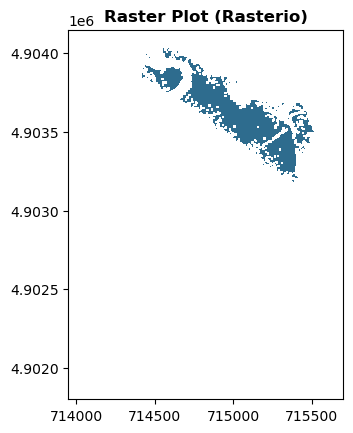

ValueError: not enough values to unpack (expected 2, got 0)

In [21]:
# Open the raster dataset
with rasterio.open(dataset) as src:
    # Plot the raster data
    show(src, title="Raster Plot (Rasterio)", cmap='viridis')
    plt.show()

In [46]:
soildataDIR = "C:/Users/RDCRLSMC/Desktop/WCP2409/soil"
os.listdir(soildataDIR)

['CRposition.xlsx',
 'fieldnotes.pdf',
 'Photos',
 'WCP-090924.xlsx',
 'WCP-091024.xlsx',
 'WCP-091124.xlsx',
 'WCP-091224.xlsx',
 'WCP-091324.xlsx',
 'WCP202409.kml']

In [47]:
soil0913 = pd.read_excel(os.path.join(soildataDIR,'WCP-091324.xlsx'))
print(soil0913)

       Name Description                  Location   Latitude   Longitude  \
0       NaN       WCPN1      GET FROM MESA TABLET        NaN         NaN   
1   Soil 11       WCPN2  44.251025°, -114.304500°  44.251025 -114.304500   
2   Soil 10       WCPN3  44.251175°, -114.306070°  44.251175 -114.306070   
3   Soil 11       WCPN4  44.252486°, -114.307587°  44.252486 -114.307587   
4   Soil 10       WCPN5  44.253518°, -114.309631°  44.253518 -114.309631   
5    Soil 9       WCPN6  44.254125°, -114.311607°  44.254125 -114.311607   
6    Soil 8       WCPN7  44.255680°, -114.313970°  44.255680 -114.313970   
7    Soil 7       WCPN8  44.256481°, -114.315103°  44.256481 -114.315103   
8   Soil 17       WCPS1  44.240203°, -114.302888°  44.240203 -114.302888   
9   Soil 16       WCPS2  44.240868°, -114.304105°  44.240868 -114.304105   
10  Soil 15       WCPS3  44.242809°, -114.305188°  44.242809 -114.305188   
11  Soil 14       WCPS4  44.244749°, -114.306806°  44.244749 -114.306806   
12  Soil 13 

In [40]:
#cols = ['Latitude','Longitude']
#soil0913[cols] = soil0913[cols].apply(pd.to_numeric, errors='coerce')
#print(soil0913[cols])

     Latitude   Longitude
0         NaN         NaN
1   44.251025 -114.304500
2   44.251175 -114.306070
3   44.252486 -114.307587
4   44.253518 -114.309631
5   44.254125 -114.311607
6   44.255680 -114.313970
7   44.256481 -114.315103
8   44.240203 -114.302888
9   44.240868 -114.304105
10  44.242809 -114.305188
11  44.244749 -114.306806
12  44.245228 -114.308161
13  44.246838 -114.308688
14  44.248256 -114.310687
15  44.249428 -114.312084


In [48]:
   # Source CRS (WGS 84 geographic)
crs_geographic = CRS("EPSG:4326")
    # Destination CRS (Web Mercator projected)
crs_projected = CRS("EPSG:32611")
transformer = Transformer.from_crs(crs_geographic, crs_projected, always_xy=True)

In [50]:
# Transform all coordinates at once
eastings, northings = transformer.transform(
    soil0913['Longitude'].values, soil0913['Latitude'].values
)

# Assign new columns
soil0913['Easting'] = eastings
soil0913['Northing'] = northings

In [51]:
with rasterio.open(dataset) as src:
    extracted_values = []
    for index, row in soil0913.iterrows():
        lon = row['Easting']
        lat = row['Northing']

        # Skip rows with NaN coordinates
        if pd.isna(lon) or pd.isna(lat):
            extracted_values.append(None)
            continue

        # Check if the point is within the raster bounds
        if (src.bounds.left <= lon <= src.bounds.right) and (src.bounds.bottom <= lat <= src.bounds.top):
            try:
                value = next(src.sample([(lon, lat)]))[0]
                extracted_values.append(value)
            except Exception as e:
                print(f"Sampling error at index {index}, coord ({lon}, {lat}): {e}")
                extracted_values.append(None)
        else:
            print(f"Point at index {index} is outside raster bounds: ({lon}, {lat})")
            extracted_values.append(None)


In [52]:
print(extracted_values)

[None, -0.11845591386936363, nan, -0.16949360095424013, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


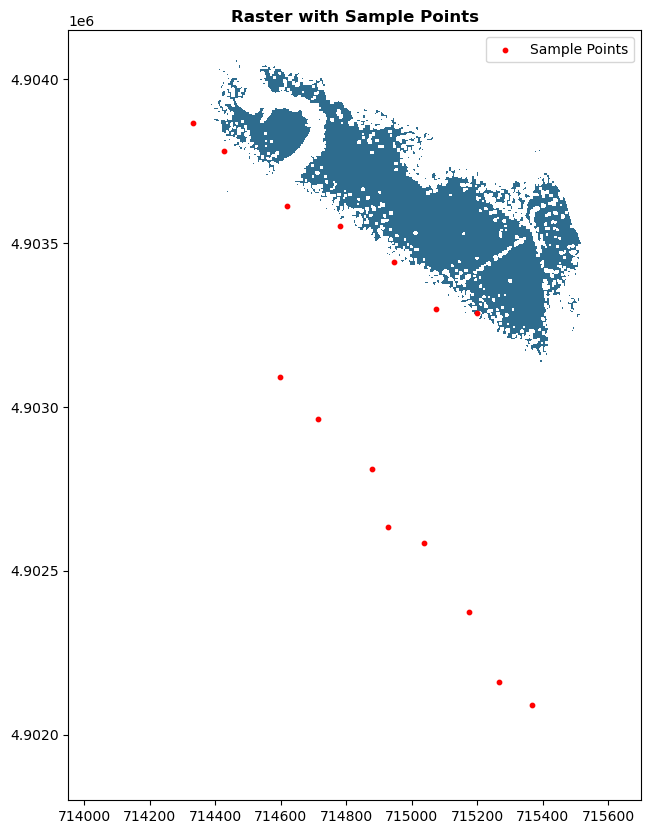

In [53]:
with rasterio.open(dataset) as src:
    # Read the raster data (first band)
    raster = src.read(1)
    
    # Plot the raster
    fig, ax = plt.subplots(figsize=(10, 10))
    rasterio.plot.show(src, ax=ax, title="Raster with Sample Points")
    
    # Plot the coordinates
    ax.scatter(
        soil0913['Easting'], soil0913['Northing'],
        c='red', s=10, label='Sample Points'
    )
    
    ax.legend()
    plt.show()